# Predicción de salario anual utilizando Random Forest
Estudiantes: Benjamín Espinoza Acevedo (benjaespinozaacevedo-ctrl) - Thomas Gómez Venegas (ThomasTg7)

# Librerias


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_validate

# Carga de datos
Utilizando el dataset Job Salary Prediction Dataset, se implementara una forma alternativa para tomar una meustra de 10.000 filas aleatorias con el fin de entrenar y probar mientras se desarrolla, ya que entrenar un modelo con una gran cantidad de datos, en este caso una cantidad de 250.000 filas se necesita tiempo para que los codigos corran, ralentizando la operacion. 

In [24]:
RUTA_CSV = "job_salary_prediction_dataset.csv"
data_completa = pd.read_csv(RUTA_CSV)
USAR_MUESTRA = True   #interruptor donde al estar en TRUE, utilizamos la muestra
N_MUESTRA    = 10000   
SEMILLA = 777                
np.random.seed(SEMILLA)

if USAR_MUESTRA:
    data = data_completa.sample(n=N_MUESTRA, random_state=SEMILLA).reset_index(drop=True)
    print("Usando la MUESTRA")
else:
    data = data_completa.copy()
    print("Usando el dataset COMPLETO")

data.head()

Usando la MUESTRA


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,Machine Learning Engineer,12,Diploma,16,Education,Large,Singapore,Hybrid,5,175931
1,Business Analyst,3,Master,12,Healthcare,Small,Canada,Yes,1,117382
2,Data Analyst,15,High School,6,Finance,Medium,Sweden,Hybrid,1,111631
3,Frontend Developer,3,Bachelor,11,Government,Medium,India,Hybrid,3,72758
4,DevOps Engineer,15,PhD,12,Retail,Enterprise,USA,No,0,263436


# Analisis de los datos
Ahora analizaremos los datos, comenzando por mirar la forma de los datos, sus tipos, si existen valores faltantes, etc.

In [25]:
print("Filas y columnas:", data.shape)
data.info()

Filas y columnas: (10000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_title         10000 non-null  object
 1   experience_years  10000 non-null  int64 
 2   education_level   10000 non-null  object
 3   skills_count      10000 non-null  int64 
 4   industry          10000 non-null  object
 5   company_size      10000 non-null  object
 6   location          10000 non-null  object
 7   remote_work       10000 non-null  object
 8   certifications    10000 non-null  int64 
 9   salary            10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


In [26]:
data.describe()

,experience_years,skills_count,certifications,salary
count,10000.000000,10000.000000,10000.00000,10000.000000
mean,9.971700,10.011500,2.45890,145480.489000
std,6.055078,5.522791,1.69393,37487.492968
min,0.000000,1.000000,0.00000,43139.000000
25%,5.000000,5.000000,1.00000,119146.000000
50%,10.000000,10.000000,2.00000,143103.000000
75%,15.000000,15.000000,4.00000,169182.500000
max,20.000000,19.000000,5.00000,327025.000000


In [27]:
data.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [28]:
data.duplicated().sum()

np.int64(0)

Luego de correr las diferentes lineas podemos observar que tenemos 10 variables, donde 4 son numericas y 6 categoricas. Dentro de las numericas tenemos la experiencia (experience_years), la cantidad de habilidades (skills_count), los certificados (certifications) y por ultimo la variable objetivo salario (salary). En cuanto a las variables numericas podemos entender diferentes datos interesantes:

Experiencia: Sabiendo que esta medida en años, donde tenemos que el rango es de 0 a 20 años, teniendo un promedio de 10 años de experiencia en los trabajadores del dataset.

Cantidad de habilidades: Tenemos que la cantidad de las habilidades van desde 1 a 19 habilidades, donde el promedio es de aproximadamente 10. 

Certificados: En cuanto a la cantidad de certificados podemos ver que el minimo es 0 y el maximo 5, donde el promedio es de 2,49.

Salarios: En cuanto a los salarios podemos ver que el minimo es de 31.867 USD al año, en cuanto al maximo tenemos 333.046 USD al año, el promedio es de 145.718 USD al año. 

In [29]:
print("Trabajos del dataset:", data["job_title"].value_counts())
print("Niveles de educacion:", data["education_level"].value_counts())
print("Industrias:", data["industry"].value_counts())
print("Tamaños de empresa:", data["company_size"].value_counts())
print("Paises del dataset:", data["location"].value_counts())
print("Indicador de trabajo remoto", data["remote_work"].value_counts())

Trabajos del dataset: job_title
Backend Developer            884
Data Scientist               858
Cybersecurity Analyst        858
Business Analyst             852
Product Manager              839
DevOps Engineer              835
Software Engineer            825
AI Engineer                  823
Data Analyst                 812
Cloud Engineer               812
Machine Learning Engineer    805
Frontend Developer           797
Name: count, dtype: int64
Niveles de educacion: education_level
Master         2022
Diploma        2004
High School    2000
Bachelor       1999
PhD            1975
Name: count, dtype: int64
Industrias: industry
Healthcare       1039
Consulting       1033
Retail           1027
Media            1023
Technology       1021
Finance          1016
Telecom          1004
Government        994
Education         927
Manufacturing     916
Name: count, dtype: int64
Tamaños de empresa: company_size
Large         2041
Enterprise    2023
Small         1982
Medium        1982
Startu

Como podemos ver en la salida anterior, podemos entender nuestras variables categoricas.

Trabajos: En esta variables podemos observar que tenemos 12 trabajos diferentes, donde son bastante uniformes en cuanto a la cantidad y todos muy relacionados con la tecnologia, negocios e ingeneria.

Niveles de educacion: En cuanto a la educacion odemos ver que tenemos 5, las cuales son Master, High School, Bachelor, PhD y Diploma.

Industrias: Los sectores de industrias identificados son de finanzas, consultoria y media. 

Tamaños de empresa: Podemos ver que hay 5 distintos tamaños de empresa, donde tenemos grandes, pequeñas, medianas, gran empresa (multinacional) y por ultimo Startup.

Paises: Los paises de los trabajadores son 10, aun uno es catalogado como remoto, intuimos que es porque el trabajador trabaja 100% remoto

Indicador de trabajo remoto: Tenemos 3 estados de indicador, donde tenemos el hibrido, si es remoto o no.


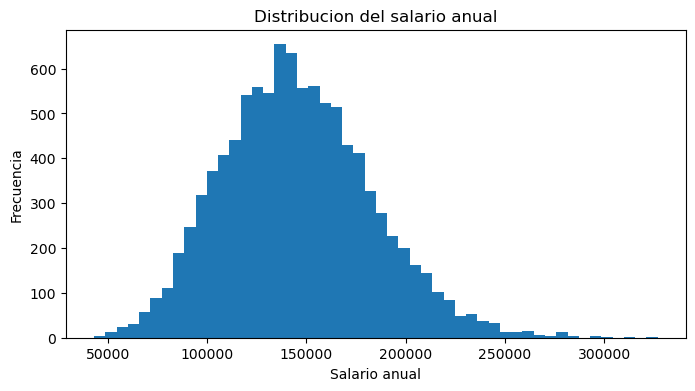

In [30]:
plt.figure(figsize=(8, 4))
plt.hist(data["salary"], bins=50)
plt.xlabel("Salario anual")
plt.ylabel("Frecuencia")
plt.title("Distribucion del salario anual")
plt.show()

Podemos ver que la distribucion del salario parece una normal, aunque un poco sesgada a la derecha. Esto nos da como ventaja que el random forest que aplicaremos, ya que tenemos pocos valores atipicos, evitando que se distorsiones fuertemente los promedios. Ademas al tener una distribucion parecida a la normal, le da mucha mas informacion para aprender los patrones en los casos mas tipicos, siendo mas preciso cuando los salarios se acercan a la media.

# Seleccion de variables
Ahora analizaremos una seleccion de variables para entender y utilizar las variables que realmente afectan al salario y descartar aquelllas que no aportar a la prediccion, ya que un modelo con menos variables y solo las mas relevantes, puede ser mas interpretable y mas facil de usar

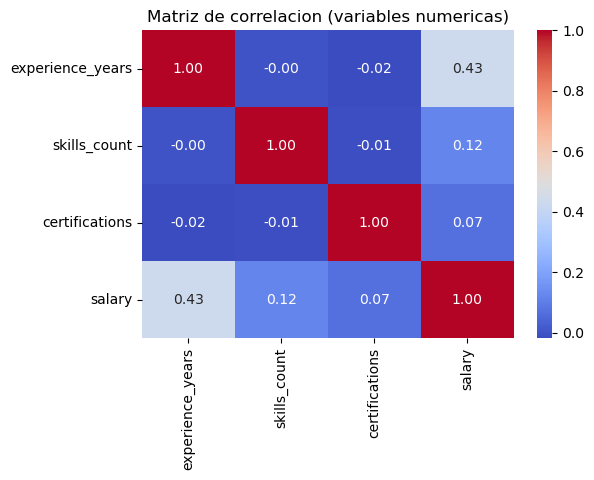

In [31]:
numericas = ["experience_years", "skills_count", "certifications", "salary"]
correlation_matrix = data[numericas].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlacion (variables numericas)")
plt.show()

Para las variables numericas, podemos simplemente generar la matriz de correlacion que vemos en la salida anterior y a partir de eso, seleccionar variables. Como podemos notar la variable con mayor correlacion es la experiencia con el salario, mientras que la cantidad de habilidades y certificados tiene una relacion bastante baja, es por esto que no las seleccionaremos para el modelo predictor, quedandonos solo con la experiencia en cuanto a las variables numericas.

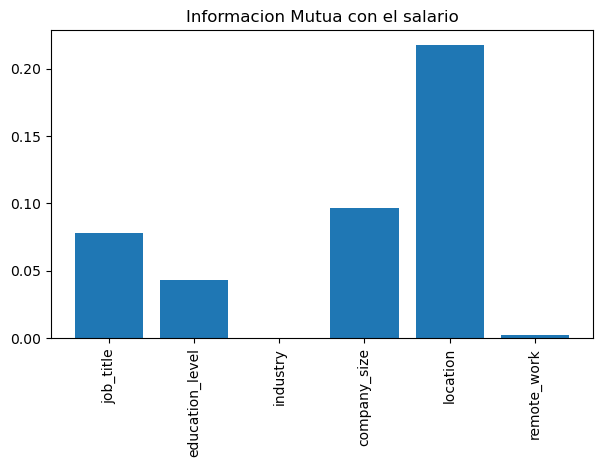

In [32]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

CAT_COLS = ["job_title", "education_level", "industry", "company_size", "location", "remote_work"]

data_encoded = data.copy()
for col in CAT_COLS:
    data_encoded[col] = LabelEncoder().fit_transform(data_encoded[col])
mi_scores = mutual_info_regression(data_encoded[CAT_COLS], data["salary"], random_state=SEMILLA)

plt.figure(figsize=(7, 4))
plt.bar(CAT_COLS, mi_scores)
plt.title("Informacion Mutua con el salario")
plt.xticks(rotation=90)
plt.show()

Para analizar las variables categoricas, sabemos que los modelos no pueden analizar texto, entonces primero debemos asignar un numero a cada categoria dentro de las variables categoricas, luego el score mide cuanta incertidumbre del salario elimina al conocer esa categoria, si el score es alto la aribale dice mucho sobre el salario sino no aporta mucho.

Aora podemos ver en el grafico que las variables que mas importantes categoricas son el pais (location), el titulo que tengan (job tittle) y el nivel de educacion (education_level), en cuanto a las otras dos variables, vemos que tienen un score extremadamente bajo, entonces no seran selecconadas para entrenar y probar el modelo.

In [33]:
VAR_NUM = ["experience_years"]
VAR_CAT = ["job_title", "location", "company_size", "education_level"]
FEATURES = VAR_NUM + VAR_CAT
print("Predictoras usadas:", FEATURES)
print("Descartadas      :", ["skills_count", "certifications", "industry", "remote_work"])

Predictoras usadas: ['experience_years', 'job_title', 'location', 'company_size', 'education_level']
Descartadas      : ['skills_count', 'certifications', 'industry', 'remote_work']


# Preprocesamiento
Ahora debemos separar la variable objetivo (salary) de las predictoras y transformamos las variables categoricas a numeros, descubrimos one-hot con pd.get_dummies y lo utilizamos porque convierte cada categoria en su propia columna 0/1 sin un orden numerico de las variables , permitiendo que el Random Forest trate cada categoría de forma independiente

In [34]:
y = data["salary"]
X = data[FEATURES]
X = pd.get_dummies(X, columns=VAR_CAT, drop_first=False)
print("Forma de X tras one-hot:", X.shape)
X.head()

Forma de X tras one-hot: (10000, 33)


,experience_years,job_title_AI Engineer,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,job_title_DevOps Engineer,job_title_Frontend Developer,...,company_size_Enterprise,company_size_Large,company_size_Medium,company_size_Small,company_size_Startup,education_level_Bachelor,education_level_Diploma,education_level_High School,education_level_Master,education_level_PhD
0,12,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
1,3,False,False,True,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,15,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
3,3,False,False,False,False,False,False,False,False,True,...,False,False,True,False,False,True,False,False,False,False
4,15,False,False,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,True


# Division en entrenamiento y prueba
Comenzamos con la division de entrenamiento y prueba, donde nos quedamos con la proporcion tipica de un 20% de los datos para probar y y el 80% para el entrenamiento, fijamos la semilla para que la particion sea la misma siempre.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (8000, 33)  Test: (2000, 33)


# Random Forest

Luego de fijar la division de entrenamiento y prueba, probaremos cuantos arboles usar mirando el error en el test, lo dejamos en RMSE para entenderlo mejor, cuando la curva deje de bajar nos indicara que agregar mas arboles no nos ayuda y solo afecta negativamente a la eficiencia computacional.

En cuanto a la profundidad de los arboles, debemos indicarle al modelo cuanto crecer, para eso tambien probaremos diferentes valores, donde analizaremos el valor de r2 tanto en el train como en el test, analizando en que valor tenemos una menor brecha entre estos valores.# Random Forest

Luego de fijar la division de entrenamiento y prueba, probaremos cuantos arboles usar mirando el error en el test, lo dejamos en RMSE para entenderlo mejor, cuando la curva deje de bajar nos indicara que agregar mas arboles no nos ayuda y solo afecta negativamente a la eficiencia computacional.

En cuanto a la profundidad de los arboles, debemos indicarle al modelo cuanto crecer, para eso tambien probaremos diferentes valores, donde analizaremos el valor de r2 tanto en el train como en el test, analizando en que valor tenemos una menor brecha entre estos valores.

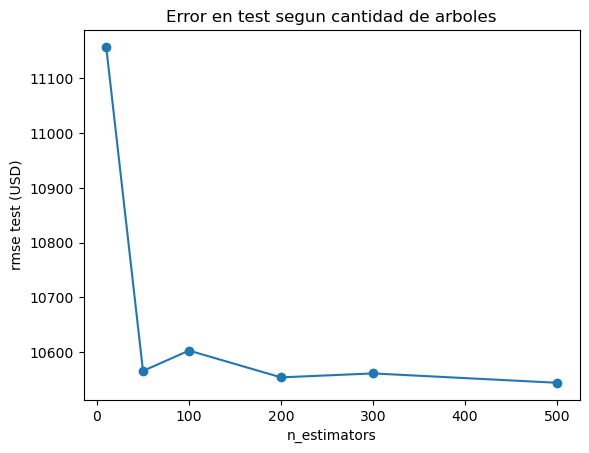

,n,rmse_test
0,10,11157.436624
1,50,10565.721166
2,100,10602.901472
3,200,10553.962501
4,300,10561.189828
5,500,10544.097423


In [36]:
df = []
for n in [10, 50, 100, 200, 300, 500]: 
    modelo = RandomForestRegressor(n_estimators=n, random_state=SEMILLA, n_jobs=-1)
    modelo.fit(X_train, y_train)
    rmse_test = np.sqrt(mean_squared_error(y_test, modelo.predict(X_test)))
    df.append({"n": n, "rmse_test": rmse_test})
df = pd.json_normalize(df)

plt.plot(df["n"], df["rmse_test"], marker="o")
plt.xlabel("n_estimators")
plt.ylabel("rmse test (USD)")
plt.title("Error en test segun cantidad de arboles")
plt.show()
df 

Como vemos en el grafico, baja abruptamente en el segundo valor, es decir con n=50, para luego mantenerse bastante estable dentro del rango de RMSE = 10600, ademas que con la tabla podemos ver mas a detalle, que en valor n=200 es el mejor valor a elegir, principalmente por la eficiencia computacional y que los valores arrojados con un numero mayor son practicamente identicos y no vale la pena generar mas arboles por una mejora tan poco significativa.

In [37]:
df = []
for prof in [5, 10, 15, 20, 25, None]: #Distintas profundidades
    modelo = RandomForestRegressor(n_estimators=200, max_depth=prof, random_state=SEMILLA, n_jobs=-1)
    modelo.fit(X_train, y_train)
    df.append({"max_depth": prof if prof else "None",
               "train_r2": r2_score(y_train, modelo.predict(X_train)),
               "test_r2": r2_score(y_test, modelo.predict(X_test))})
df = pd.json_normalize(df)
df

,max_depth,train_r2,test_r2
0,5,0.637680,0.623245
1,10,0.877715,0.841306
2,15,0.962935,0.912563
3,20,0.984108,0.922143
4,25,0.987439,0.921625
5,None,0.987652,0.921698


Ahora vemos la profundidad, para manejar tambien el overfitting, la idea fue probar con diferentes valores para entender el mejor, en cuanto a eficiencia computacional y resultados, como podemos ver con max_depth= 20 se alcanza un punto optimo, ya que luego las mejoras no son significativas con ramificaciones mayores. 

Con esto, hemos elegido nuestros parametros, donde tendremos un modelo donde usamos 200 arboles y con una profundidad de 20

In [38]:
modelo = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=SEMILLA, n_jobs=-1) 
modelo.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Validacion cruzada k-fold (norma L2 / MSE)
Mediremos la generalizacion del modelo con k-fold, partiendo el train en 5 conjuntos, donde 4 se usaran para entrenar, 1 para rotar y usarlo de test. El valor de k=5 se eligio principalmente porque leimos que era un valor estandar, ademas de ser utilizado tanto en clases como en los notebooks del repositorio del curso.

Usaremos el error cuadratico medio como funcion de costo, minimizando con la norma L2

In [39]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)
cv = cross_validate(
    modelo, X_train, y_train,
    scoring=["neg_mean_squared_error"],
    cv=kf, n_jobs=-1
)
mse_folds = -cv["test_neg_mean_squared_error"]
print("MSE por fold:", mse_folds.round(0))
print("MSE medio   :", round(mse_folds.mean(), 0))
print("RMSE medio  :", round(np.sqrt(mse_folds.mean()), 0))

MSE por fold: [1.05169334e+08 1.13996708e+08 1.15135632e+08 1.11060547e+08
 1.11142193e+08]
MSE medio   : 111300883.0
RMSE medio  : 10550.0


In [40]:
y_pred = modelo.predict(X_test)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
r    = np.sqrt(r2)
print("MSE :", round(mse, 0))
print("RMSE:", round(rmse, 0))
print("R2  :", round(r2, 4))
print("r   :", round(r, 4))

MSE : 110753296.0
RMSE: 10524.0
R2  : 0.9221
r   : 0.9603


Viendo las salidas podemos ver que el modelo sobre el conjunto que no vio predice con un error medio de 10.550 USD, sabiendo antes que el salario promedio es de 145.480, teniendo un R2 de 0.9221, nos indica que el modelo explica aproximadamente el 92% de la variacion de los salarios, usando las cinco variables que seleccionamos, podriamos decir que el modelo generaliza bien y no sufre de overfitting

# Predicho vs Real
Ahora crearemos un grafico donde cada punto es un trabajador del test: eje X = salario real, eje Y = salario predicho, mientras mas
pegados esten los puntos a la diagonal roja, mejor predice el modelo

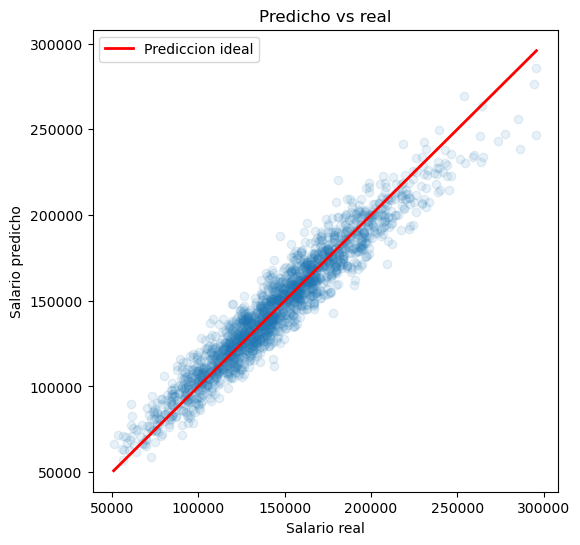

In [41]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.1)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color="red", linewidth=2, label="Prediccion ideal")
plt.xlabel("Salario real")
plt.ylabel("Salario predicho")
plt.title("Predicho vs real")
plt.legend()
plt.show()

Podemos notar que los puntos se pegan bien a la diagonal, esto nos confirma que el modelo predice bien y en todo el rango de salarios, los puntos se concentran mucho mas entre 100.000 y 200.000 USD. Tambien podemos ver que en el extremo superior derecho, hay menos datos y mas dispersos, es decir que el modelo predice peor ya que son valores atipicos y se guia mas por el promedio, pero es esperable y normal con valores demasiado atipicos.

# Importancia de las variables
Random Forest nos entrega la importancia de cada columna, como el one-hot crea varias columnas por variable, las sumamos por grupo para obtener la importancia de la variable original. Aca esperamos que el pais, es decir la varaible location sea la mas importante, ya que el nivel socioeconomico de cada pais influye directamente en cuanto se paga por un mismo trabajo.

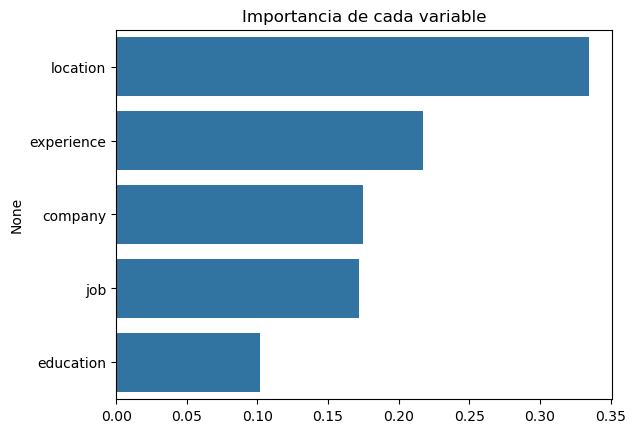

location      0.334396
experience    0.217180
company       0.174641
job           0.172120
education     0.101663
dtype: float64

In [42]:
importancias = pd.Series(modelo.feature_importances_, index=X.columns)
categorias = ["location", "experience", "company", "job", "education"]

def categorizar(columna):
    for categoria in categorias:
        if categoria in columna:
            return categoria
importancias_categorias = (importancias
       .groupby([categorizar(c) for c in X.columns])
       .sum()
       .sort_values(ascending=False))

sns.barplot(x=importancias_categorias.values, y=importancias_categorias.index)
plt.title("Importancia de cada variable")
plt.show()
importancias_categorias

Como habiamos intuido, la variable mas importante es el pais, con mas de un 30% de importancia, como segunda vemos que es la experiencia, siendo mayor al 20%, por ultimo tenemos el tamaño de la compañia, el trabajo y la educacion. Sorprende que la educacion sea la variable menos importante, siendo que esta podria ser percibida como una importante variable a considerar cuando se piensa en efectos sobre nuestro salario futuro y vemos que mucho mas importante la cantidad de años que llevaras en tu trabajo

# Linealidad del efecto de la experiencia sobre el salario
Ahora analizaremos como se comporta el efecto de la experiencia sobre el salario de los trabajadores, para esto debemos aislar el efecto de la experiencia sobre el salario que predice el modelo, aa idea es tomar a todos los trabajadores del test y les cambiamos solo la experiencia, desde 0 hasta 20 años, dejando todo lo demas igual. Para cada valor de experiencia calculamos el salario promedio que predice el modelo. Asi vemos cuanto sube el salario solo por tener mas experiencia, sin que influyan las otras variables. Despues graficamos esos promedios y agregamos una recta que une el inicio con el final.

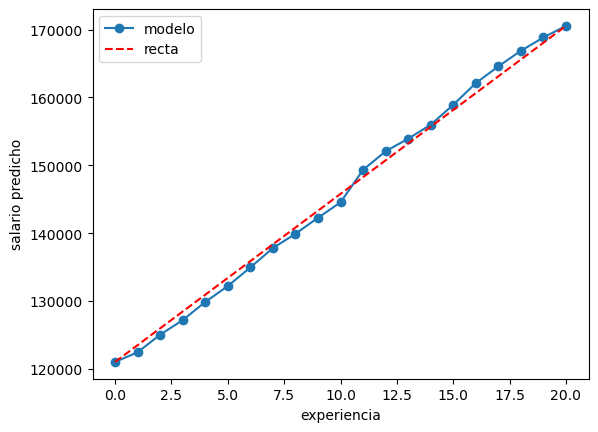

In [43]:
perfiles = X_test.copy()   # todos los perfiles del test, no una muestra
exp = []
for e in range(0, 21):
    perfiles["experience_years"] = e   # le cambiamos solo la experiencia
    exp.append(modelo.predict(perfiles).mean())

plt.plot(range(0, 21), exp, marker="o", label="modelo")
plt.plot([0, 20], [exp[0], exp[-1]], "--", color="red", label="recta")
plt.xlabel("experiencia")
plt.ylabel("salario predicho")
plt.legend()
plt.show()

Podemos notar que el modelo nos muestra que el efecto de la experiencia sobre el salario es practicamente lineal, las predicciones del modelo siguen muy de cerca a la recta de referencia en todo el rango, esto significa que cada año adicional de experiencia aporta aproximadamente lo mismo al salario. Se observan desviaciones muy pequeñas respecto a la recta, pero son minimas y no muestran un patron claro, por lo que podemos concluir que el modelo trata la experiencia como una variable de efecto practicamente lineal sobre el salario

# Probar el modelo
Ahora crearemos la funcion para predecir nuestro salario con el modelo creado, indicando las variables de años de experiencia, cargo, pais, tamaño de empresa y educacion

In [44]:
def predecir_salario(experiencia, cargo, pais, tamano, educacion):
    fila = pd.DataFrame([{
        "experience_years": experiencia,
        "job_title": cargo,
        "location": pais,
        "company_size": tamano,
        "education_level": educacion,
    }])
    fila = pd.get_dummies(fila, columns=VAR_CAT) 
    fila = fila.reindex(columns=X.columns, fill_value=0) 
    return modelo.predict(fila)[0]

print(predecir_salario(10, "Data Analyst", "USA", "Large", "Master"))
print(predecir_salario(10, "Data Analyst", "India", "Large", "Master"))

156908.15083333332
90997.5275


Ahora utilizamos la funcion y agregamos los inputs para que el usuario pueda probarlo con sus variables, ademas imprimimos las posibles respuestas que debe dar el usuario

In [46]:
print("Cargos disponibles:", sorted(data["job_title"].unique()))
print("Paises disponibles:", sorted(data["location"].unique()))
print("Tamaños de empresa:", sorted(data["company_size"].unique()))
print("Niveles de educacion:", sorted(data["education_level"].unique()))
print("Experiencia: un numero entero entre 0 y 20")
print()

exp = int(input("experiencia (0-20): "))
cargo = input("cargo: ")
pais = input("pais: ")
tamano = input("tamano empresa: ")
edu = input("educacion: ")
print("salario estimado:", round(predecir_salario(exp, cargo, pais, tamano, edu)))

Cargos disponibles: ['AI Engineer', 'Backend Developer', 'Business Analyst', 'Cloud Engineer', 'Cybersecurity Analyst', 'Data Analyst', 'Data Scientist', 'DevOps Engineer', 'Frontend Developer', 'Machine Learning Engineer', 'Product Manager', 'Software Engineer']
Paises disponibles: ['Australia', 'Canada', 'Germany', 'India', 'Netherlands', 'Remote', 'Singapore', 'Sweden', 'UK', 'USA']
Tamaños de empresa: ['Enterprise', 'Large', 'Medium', 'Small', 'Startup']
Niveles de educacion: ['Bachelor', 'Diploma', 'High School', 'Master', 'PhD']
Experiencia: un numero entero entre 0 y 20

salario estimado: 182669


# Conclusiones
Dentro de proyecto pudimos crear un modelo predictor utilizando random forest, evaluado con k-fold y mse, indicando variables significativas como son los años de experiencia, cargo, pais, tamaño de la empresa y nivel de educacion. En la creacion del modelo se generaron instancias de analisis como la seleccion de variable, analizando las mas importantes y significativas para el efecto predictor del salario, ademas de probar los parametros del modelo random forest, donde terminamos eligiendo 200 arboles y 20 ramificaciones, intentando optimizar la eficiencia computacional y el riesgo de overfitting.

Analizamos algunas hipostesis, donde verificamos que la varible que mayor efecto tiene sobre el salario es el pais en donde trabajamos o de donde nos contratan (location) y que seguido de esto son los años de experiencia, tambien notamos entre las variables importantes para el efecto del salario, la educacion era la que menos efecto tenia.

En cuanto a la linealidad de la experiencia, fallamos en nuestra hipotesis y pudimos ver, gracias al grafico que el efecto de la experiencia sobre los salarios es practicamente lineal, aportando practicamente la misma cantidad de dinero, por año de experiencia, sin importar el cuando.